# Plus-Minus QNN — Blind Quantum Computing (BQC) | Cenário 1

Este notebook demonstra o treinamento de uma Rede Neural Quântica (QNN) integrada a uma simulação de rede quântica para o **Cenário 1**. O objetivo é classificar o dataset Plus-Minus em um ambiente onde o ruído do simulador é ditado pela fidelidade da infraestrutura de rede.

**Principais diferenciais deste cenário:**
* **Topologia Dinâmica:** Simulação de uma rede em grade onde múltiplos clientes podem iniciar requisições.
* **Redução PCA:** Compactação de imagens para 2 dimensões para viabilizar o processamento quântico.
* **Coevolução Rede-Modelo:** A acurácia do modelo influencia a fidelidade da rede, que por sua vez altera o ruído do treinamento na época seguinte.

In [18]:
!pip install aiohttp fsspec h5py


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\Dreysv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:
import sys
print(sys.executable)

!{sys.executable} -m pip install pennylane

C:\Users\Dreysv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\Dreysv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [20]:
# Instalar dependências
!pip install qiskit qiskit-aer qiskit-machine-learning qiskit-algorithms scikit-learn matplotlib numpy
!pip install pennylane pennylane-datasets


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\Dreysv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


ERROR: Could not find a version that satisfies the requirement pennylane-datasets (from versions: none)
ERROR: No matching distribution found for pennylane-datasets

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\Dreysv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [21]:
# Imports
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Qiskit
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliFeatureMap, RealAmplitudes
from qiskit.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.quantum_info import SparsePauliOp

# Simulador e ruído
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Dataset e métricas
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Rede BQC
from quantumnet.components import Controller, Logger, Network

# PennyLane dataset
import pennylane as qml

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Controle de Aleatoriedade e Parâmetros Base

Garantimos a reprodutibilidade dos resultados fixando as *seeds* em todas as bibliotecas utilizadas (Python, NumPy, PyTorch e Qiskit). Também definimos o número de execuções (`SHOTS = 128`) para os circuitos quânticos e estabelecemos o protocolo de roteamento BFK_BQC que será utilizado na rede quântica.

In [22]:
# Controle de aleatoriedade
SEED = 512
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

try:
    from qiskit_algorithms.utils import algorithm_globals
    algorithm_globals.random_seed = SEED
except:
    pass


Configuração da Rede Quântica e Topologia

Nesta seção, inicializamos a `quantumnet` com uma topologia específica para o Cenário 1.
* **Topologia:** Uma grade configurada para simular a distribuição entre diversos clientes e um servidor central (Bob).
* **Protocolo AC_BQC:** Implementação do protocolo de computação cega para garantir a privacidade dos dados delegados.
* **Função de Envio:** A função `enviar_circuito_por_epoca` seleciona aleatoriamente um dos clientes disponíveis para realizar a requisição, simulando o tráfego real de uma rede quântica multiusuário.

2026-01-14 15:04:38,476: Host 10 é o servidor, não receberá qubits.
2026-01-14 15:04:38,478: Host 13 inicializado com 0 qubits.
2026-01-14 15:04:38,479: Host 8 inicializado com 0 qubits.
2026-01-14 15:04:38,480: Host 2 inicializado com 0 qubits.
2026-01-14 15:04:38,481: Host 6 inicializado com 0 qubits.
2026-01-14 15:04:38,482: Host 0 inicializado com 0 qubits.
2026-01-14 15:04:38,483: Host 3 inicializado com 0 qubits.
2026-01-14 15:04:38,484: Host 11 inicializado com 0 qubits.
2026-01-14 15:04:38,485: Host 15 inicializado com 0 qubits.
2026-01-14 15:04:38,485: Host 1 inicializado com 0 qubits.
2026-01-14 15:04:38,486: Host 4 inicializado com 0 qubits.
2026-01-14 15:04:38,487: Host 5 inicializado com 0 qubits.
2026-01-14 15:04:38,487: Host 7 inicializado com 0 qubits.
2026-01-14 15:04:38,487: Host 9 inicializado com 0 qubits.
2026-01-14 15:04:38,488: Host 12 inicializado com 0 qubits.
2026-01-14 15:04:38,489: Host 14 inicializado com 0 qubits.
2026-01-14 15:04:38,490: Par EPR <quantumn

Hosts inicializados
Canais inicializados
Pares EPRs adicionados


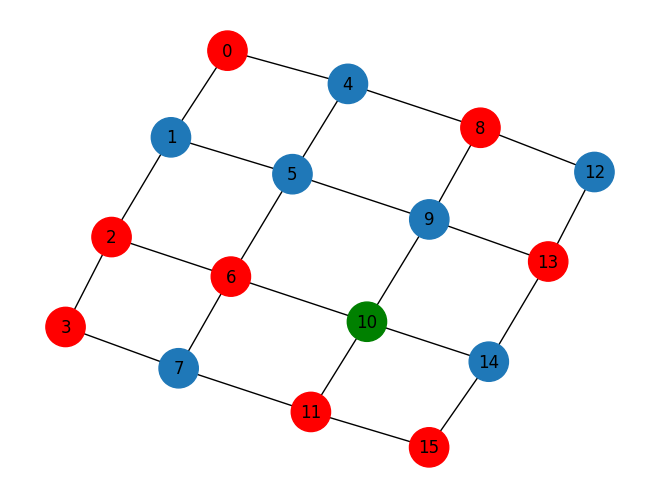

In [ ]:
SHOTS = 128
protocolo = "AC_BQC"

rede = Network()
controlador = Controller(rede)

clientes = [13, 8, 2, 6, 0, 3, 11, 15]
server = 10

rede.set_ready_topology(
    'grade',
    8, 4, 4,
    clients=clientes,
    server=server
)

rede.draw()
Logger.activate(Logger)

def enviar_circuito_por_epoca(
    circuito,
    epoch,
    num_qubits,
    circuit_depth,
    rede,
    controlador,
    protocolo=protocolo
):
    print(f"[Epoch {epoch+1}] Enviando circuito — CENÁRIO 1")

    alice_id = random.choice([13, 8, 2, 6, 0, 3, 11, 15])
    bob_id = 10

    request = rede.generate_request(
        alice_id=alice_id,
        bob_id=bob_id,
        num_qubits=num_qubits,
        num_gates=circuit_depth,
        scenario=1
    )

    request["quantum_circuit"] = circuito
    request["protocol"] = protocolo

    controlador.receive_request(request)

    controlador.process_requests()
    controlador.send_scheduled_requests()

    print(
        f"[Epoch {epoch+1}] "
        f"Alice={alice_id} → Bob={bob_id} | Protocolo={protocolo}"
    )



# Processamento do Dataset Plus-Minus (PCA)

O dataset Plus-Minus consiste em imagens simples de sinais "+" e "-". Para processá-las em uma QNN:
1. **Redução de Dimensionalidade:** Utilizamos **PCA** para extrair as 2 componentes principais, permitindo o uso de apenas 2 qubits.
2. **Normalização:** Aplicamos o `MinMaxScaler` para que os dados fiquem no intervalo [0, 1], ideal para os parâmetros das portas de rotação.
3. **Preparação PyTorch:** Os dados são convertidos em tensores e organizados em `DataLoaders` para o treinamento por lotes (minibatches).

In [ ]:

try:
    [ds] = qml.data.load("plus-minus", force=True)
except:
    [ds] = qml.data.load("plus-minus", force=True, folder_path="./data")


[ds] = qml.data.load("plus-minus", force=True, folder_path="./data")


X = ds.img_train
y = ds.labels_train
X_test = ds.img_test
y_test = ds.labels_test

X = X.reshape((X.shape[0], -1))
X_test = X_test.reshape((X_test.shape[0], -1))

pca = PCA(n_components=2, random_state=SEED)
X = pca.fit_transform(X)
X_test = pca.transform(X_test)

scaler = MinMaxScaler((0, 1))
X = scaler.fit_transform(X)
X_test = scaler.transform(X_test)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

def to_01(arr):
    arr = np.array(arr).astype(np.float32)
    return ((arr > 0).astype(np.float32)).reshape(-1, 1)

y_train = to_01(y_train)
y_val = to_01(y_val)
y_test = to_01(y_test)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)


y_train_tensor = torch.tensor(y_train, dtype=torch.long).squeeze()
y_val_tensor   = torch.tensor(y_val, dtype=torch.long).squeeze()
y_test_tensor  = torch.tensor(y_test, dtype=torch.long).squeeze()



# Arquitetura do Circuito Quântico 

Construímos a rede neural quântica utilizando a biblioteca `qiskit-machine-learning`:
* **Feature Map (`PauliFeatureMap`):** Responsável por codificar os dados clássicos (vitos pelo PCA) em estados quânticos complexos.
* **Ansatz (`RealAmplitudes`):** A parte treinável do circuito, contendo camadas de rotações e emaranhamento.
* **Observáveis:** Medimos o valor de expectativa no eixo Z para fornecer a saída numérica que será processada pela função de perda do PyTorch.

In [ ]:

num_qubits = X_train.shape[1]   
num_classes = len(np.unique(y)) 

print(num_qubits, num_classes)

feature_map = PauliFeatureMap(
    num_qubits,
    paulis=['X', 'Z', 'ZZ'],
    reps=2
)


ansatz = RealAmplitudes(
    num_qubits,
    reps=1
)

qc = QuantumCircuit(num_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

observables = [
    SparsePauliOp.from_list([
        ("I" * i + "Z" + "I" * (num_qubits - i - 1), 1.0)
    ])
    for i in range(num_qubits)
]


2 4


# Gerenciamento Dinâmico de Ruído e Integração

A função `gerenciar_ruido` é o coração da simulação física. Ela mapeia a **Fidelidade da Rota** calculada pela camada de aplicação da rede para parâmetros de erro no `AerSimulator`. 
* Isso garante que, se a rede estiver instável (baixa fidelidade), o treinamento da QNN sofrerá com mais ruído, imitando um computador quântico real acessado via rede.

In [ ]:

def gerenciar_ruido(rede=None, num_qubits=4):
    """Versão adaptada do gerenciador de ruído para IRIS com BackendSampler"""
    
    noise_p = 0.01 
    
    if rede is None:
        print("[gerenciar_ruido] Rede não disponível — mantendo ruído padrão.")
        simulator = AerSimulator(shots=SHOTS)
        return simulator, noise_p
    
    try:
        
        fidelity = 0.8  
        
        if hasattr(rede, 'application_layer') and rede.application_layer:
            try:
                if hasattr(rede.application_layer, 'route_fidelities') and rede.application_layer.route_fidelities:
                    fidelities = rede.application_layer.route_fidelities
                    fidelity = sum(fidelities) / len(fidelities)
                    fidelity = max(0.6, min(0.99, fidelity))
                else:
                    fidelity = rede.application_layer.avg_fidelity_on_applicationlayer()
            except:
                fidelity = 0.8
        
        if fidelity >= 0.95:
            noise_p = 0.001 
        elif fidelity >= 0.90:
            noise_p = 0.004
        elif fidelity >= 0.85:
            noise_p = 0.005
        elif fidelity >= 0.80:
            noise_p = 0.008
        elif fidelity >= 0.75:
            noise_p = 0.01
        elif fidelity >= 0.70:
            noise_p = 0.02
        elif fidelity >= 0.65:
            noise_p = 0.04
        elif fidelity >= 0.60:
            noise_p = 0.08
        else:
            noise_p = 0.25 
        
        print(f" MAPEAMENTO: F={fidelity:.3f} → noise_p={noise_p:.3f}")
        
        dynamic_noise = NoiseModel()
        
        error_single = depolarizing_error(noise_p, 1)
        dynamic_noise.add_all_qubit_quantum_error(error_single, 
            ['id', 'x', 'y', 'z', 'h', 's', 'sdg', 't', 'tdg', 'rx', 'ry', 'rz'])
        
        error_double = depolarizing_error(min(0.5, noise_p * 3), 2)
        dynamic_noise.add_all_qubit_quantum_error(error_double, ['cx', 'cz', 'swap'])
        
        simulator = AerSimulator(
            noise_model=dynamic_noise, 
            shots=SHOTS,
            method='density_matrix',
            seed_simulator=SEED
        )
        
        return simulator, noise_p
        
    except Exception as e:
        print(f"ERRO em gerenciar_ruido: {e}")
        simulator = AerSimulator(shots=SHOTS)
        return simulator, 0.01 



In [ ]:

simulator = AerSimulator(shots=SHOTS)
estimator = Estimator(options={"backend": simulator})

qnn = EstimatorQNN(
    circuit=qc,
    estimator=estimator,
    observables=observables,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters
)

initial_weights = 0.01 * np.random.randn(qnn.num_weights)

model = TorchConnector(qnn, initial_weights=initial_weights)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.05)


C:\Users\Dreysv\AppData\Local\Temp\ipykernel_6396\1928820337.py:3: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator(options={"backend": simulator})
C:\Users\Dreysv\AppData\Local\Temp\ipykernel_6396\1928820337.py:6: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  qnn = EstimatorQNN(


# Treinamento Híbrido e Feedback da Rede

O loop de treinamento integra a otimização clássica (Adam) com a execução quântica. 
* **Processo:** A cada época, o simulador é atualizado com o ruído atual, os pesos são ajustados via backpropagation e a acurácia resultante é usada para atualizar a fidelidade das rotas na rede através de um fator de suavização (`FID_ALPHA`).
* Ao final de cada época, o circuito atualizado é "enviado" via rede quântica para simular a produção.

In [ ]:
num_epochs = 20
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

train_losses = []
train_accuracies = []
test_accuracies = []

FID_ALPHA = 0.5

for epoch in range(num_epochs):
    print(f"\n=== ÉPOCA {epoch+1}/{num_epochs} ===")

    simulator_updated, noise_used = gerenciar_ruido(rede)
    estimator_updated = Estimator(options={"backend": simulator_updated})
    model.neural_network.estimator = estimator_updated


    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data)            
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()


        total_loss += loss.item()
        _, predicted = torch.max(output, 1)
        correct += (predicted == target).sum().item()
        total += target.size(0)

    train_acc = correct / total

    model.eval()
    with torch.no_grad():
        out_test = model(X_test_tensor)
        _, pred_test = torch.max(out_test, 1)
        test_acc = (pred_test == y_test_tensor).sum().item() / len(y_test_tensor)

    f_ant = rede.application_layer.avg_fidelity_on_applicationlayer()
    f_target = 0.6 + test_acc * 0.38
    nova_fidelidade = FID_ALPHA * f_ant + (1 - FID_ALPHA) * f_target

    rede.application_layer.route_fidelities = [
        nova_fidelidade for _ in rede.application_layer.route_fidelities
    ]

    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Loss: {train_losses[-1]:.4f}")
    print(f"Acurácia treino: {train_acc:.4f} | teste: {test_acc:.4f}")
    print(f"Fidelidade: {nova_fidelidade:.4f}")

    enviar_circuito_por_epoca(
    circuito=qc,
    epoch=epoch,
    num_qubits=num_qubits,
    circuit_depth=qc.depth(),
    rede=rede,
    controlador=controlador,
    protocolo=protocolo
    )


2026-01-14 15:04:44,254: Nenhuma fidelidade foi registrada na camada de aplicação.



=== ÉPOCA 1/20 ===
 MAPEAMENTO: F=0.000 → noise_p=0.250


C:\Users\Dreysv\AppData\Local\Temp\ipykernel_6396\1384336515.py:18: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator_updated = Estimator(options={"backend": simulator_updated})
2026-01-14 15:05:14,060: Nenhuma fidelidade foi registrada na camada de aplicação.
2026-01-14 15:05:14,076: Circuito aleatório gerado com 2 qubits e 2 portas. Instruções sobre o circuito.
2026-01-14 15:05:14,076: Instrução: {'operation': 'swap', 'qubits': [0, 1]}
2026-01-14 15:05:14,077: Instrução: {'operation': 's', 'qubits': [1]}
2026-01-14 15:05:14,077: Requisição adicionada: Alice 3 -> Bob 10 com protocolo BFK_BQC e cenário 1.
2026-01-14 15:05:14,078: Requisição recebida: {'alice_id': 3, 'bob_id'

Loss: 0.5931
Acurácia treino: 0.7562 | teste: 0.9250
Fidelidade: 0.4758
[Epoch 1] Enviando circuito — CENÁRIO 1
             
q_0: ─X──────
      │ ┌───┐
q_1: ─X─┤ S ├
        └───┘
Tempo de Operação: 2
Pares EPRs adicionados
Hosts inicializados
[Epoch 1] Alice=3 → Bob=10 | Protocolo=AC_BQC

=== ÉPOCA 2/20 ===
 MAPEAMENTO: F=0.990 → noise_p=0.001


2026-01-14 15:05:42,162: A média das fidelidades das rotas é: 1.0000
2026-01-14 15:05:42,176: Circuito aleatório gerado com 2 qubits e 2 portas. Instruções sobre o circuito.
2026-01-14 15:05:42,177: Instrução: {'operation': 'x', 'qubits': [1]}
2026-01-14 15:05:42,177: Instrução: {'operation': 'h', 'qubits': [1]}
2026-01-14 15:05:42,178: Requisição adicionada: Alice 3 -> Bob 10 com protocolo BFK_BQC e cenário 1.
2026-01-14 15:05:42,178: Requisição recebida: {'alice_id': 3, 'bob_id': 10, 'num_qubits': 2, 'quantum_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001D0BC3BD950>, 'circuit_depth': 2, 'protocol': 'AC_BQC', 'slice_path': None, 'scenario': 1}
2026-01-14 15:05:42,179: Rota válida encontrada: [3, 2, 6, 10]
2026-01-14 15:05:42,179: Rota reservada: [3, 2, 6, 10] no timeslot 9.
2026-01-14 15:05:42,180: Requisição agendada: {'alice_id': 3, 'bob_id': 10, 'num_qubits': 2, 'quantum_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001D0BC3BD950

...

Loss: 0.4221
Acurácia treino: 0.9150 | teste: 0.9300
Fidelidade: 0.9561
[Epoch 19] Enviando circuito — CENÁRIO 1
             
q_0: ──■───■─
     ┌─┴─┐ │ 
q_1: ┤ X ├─■─
     └───┘   
Tempo de Operação: 2
Pares EPRs adicionados
Hosts inicializados
[Epoch 19] Alice=3 → Bob=10 | Protocolo=AC_BQC

=== ÉPOCA 20/20 ===
 MAPEAMENTO: F=0.958 → noise_p=0.001


2026-01-14 15:13:37,414: A média das fidelidades das rotas é: 0.9584


Loss: 0.4223
Acurácia treino: 0.9062 | teste: 0.9250
Fidelidade: 0.9550
[Epoch 20] Enviando circuito — CENÁRIO 1
          ┌───┐
q_0: ──■──┤ X ├
     ┌─┴─┐└─┬─┘
q_1: ┤ X ├──■──
     └───┘     


2026-01-14 15:13:37,677: Circuito aleatório gerado com 2 qubits e 2 portas. Instruções sobre o circuito.
2026-01-14 15:13:37,677: Instrução: {'operation': 'cx', 'qubits': [0, 1]}
2026-01-14 15:13:37,677: Instrução: {'operation': 'cx', 'qubits': [1, 0]}
2026-01-14 15:13:37,677: Requisição adicionada: Alice 13 -> Bob 10 com protocolo AC_BQC e cenário 1.
2026-01-14 15:13:37,677: Requisição recebida: {'alice_id': 13, 'bob_id': 10, 'num_qubits': 2, 'quantum_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001D0BC3BD950>, 'circuit_depth': 2, 'protocol': 'AC_BQC', 'slice_path': None, 'scenario': 1}
2026-01-14 15:13:37,677: Rota válida encontrada: [13, 9, 10]
2026-01-14 15:13:37,677: Rota reservada: [13, 9, 10] no timeslot 150.
2026-01-14 15:13:37,677: Requisição agendada: {'alice_id': 13, 'bob_id': 10, 'num_qubits': 2, 'quantum_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001D0BC3BD950>, 'circuit_depth': 2, 'protocol': 'AC_BQC', 'slice_path': No

Tempo de Operação: 2
Pares EPRs adicionados
Hosts inicializados
[Epoch 20] Alice=13 → Bob=10 | Protocolo=AC_BQC


# Avaliação de Performance e Métricas de Rede

Nesta etapa final, geramos o diagnóstico completo do sistema:
1. **Métricas Clássicas:** Acurácia, F1-Score e Matriz de Confusão para validar a classificação.
2. **Análise Visual:** Gráficos de perda e acurácia para verificar a convergência.
3. **Métricas de Infraestrutura:** Quantidade de **pares EPR** consumidos pela rede e a fidelidade final atingida pelas rotas de comunicação.

In [ ]:
def mostrar_matriz_confusao(y_true, y_pred, classes=None, title='Matriz de Confusão'):
    """Mostra matriz de confusão formatada"""
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n{title}")
    print("=" * 40)
    
    if classes is None:
        classes = [f'Classe {i}' for i in range(len(cm))]
    
    header = "         " + " ".join(f"{cls:>8}" for cls in classes)
    print(header)
    print(" " * 9 + "-" * (len(classes) * 9))
    
    for i, row in enumerate(cm):
        row_str = f"{classes[i]:<8} |"
        for val in row:
            row_str += f" {val:>7}"
        print(row_str)
    
    return cm

In [30]:
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    _, y_pred = torch.max(y_pred_tensor, 1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nMÉTRICAS FINAIS")
print(f"Acurácia : {accuracy:.4f}")
print(f"Precisão : {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nRELATÓRIO:")
print(classification_report(y_test, y_pred, target_names=["minus", "plus"]))



MÉTRICAS FINAIS
Acurácia : 0.9250
Precisão : 0.9655
Recall   : 0.9333
F1-score : 0.9492

RELATÓRIO:
              precision    recall  f1-score   support

       minus       0.82      0.90      0.86        50
        plus       0.97      0.93      0.95       150

    accuracy                           0.93       200
   macro avg       0.89      0.92      0.90       200
weighted avg       0.93      0.93      0.93       200



In [ ]:
print("\n" + "="*60)
print("AVALIAÇÃO FINAL DO MODELO")
print("="*60)

model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    _, y_pred_labels = torch.max(y_pred_tensor.data, 1)
    y_pred = y_pred_labels.numpy()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nMÉTRICAS GLOBAIS:")
print(f"Acurácia  : {accuracy:.4f}")
print(f"Precisão  : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print(f"\nRELATÓRIO DE CLASSIFICAÇÃO:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["minus", "plus"]
    )
)

print("\nMATRIZ DE CONFUSÃO:")
cm = mostrar_matriz_confusao(
    y_test,
    y_pred,
    classes=["minus", "plus"],
    title="Matriz de Confusão - PLUS-MINUS QNN"
)





AVALIAÇÃO FINAL DO MODELO

MÉTRICAS GLOBAIS:
Acurácia  : 0.9250
Precisão  : 0.9287
Recall    : 0.9250
F1-Score  : 0.9262

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

       minus       0.82      0.90      0.86        50
        plus       0.97      0.93      0.95       150

    accuracy                           0.93       200
   macro avg       0.89      0.92      0.90       200
weighted avg       0.93      0.93      0.93       200


MATRIZ DE CONFUSÃO:

Matriz de Confusão - PLUS-MINUS QNN
            minus     plus
         ------------------
minus    |      45       5
plus     |      10     140


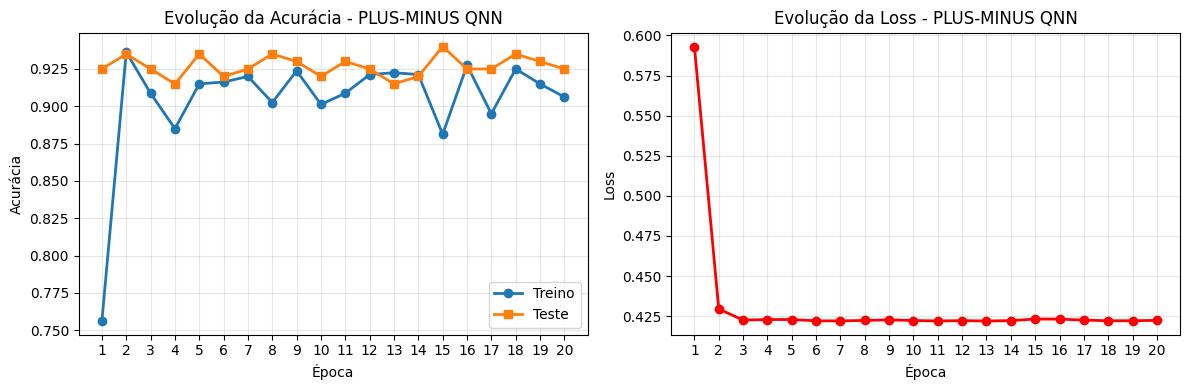

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, num_epochs + 1), train_accuracies, 'o-', label='Treino', linewidth=2)
ax1.plot(range(1, num_epochs + 1), test_accuracies, 's-', label='Teste', linewidth=2)
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.set_title('Evolução da Acurácia - PLUS-MINUS QNN')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, num_epochs + 1))

ax2.plot(range(1, num_epochs + 1), train_losses, 'o-', color='red', linewidth=2)
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.set_title('Evolução da Loss - PLUS-MINUS QNN')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, num_epochs + 1))

plt.tight_layout()
plt.show()


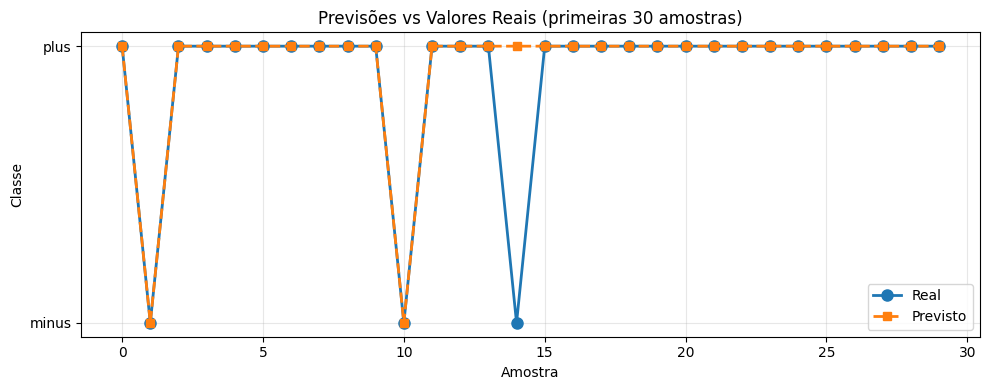

In [ ]:

plt.figure(figsize=(10, 4))
n_samples = min(30, len(y_test))

plt.plot(
    y_test[:n_samples],
    'o-',
    label='Real',
    markersize=8,
    linewidth=2
)

plt.plot(
    y_pred[:n_samples],
    's--',
    label='Previsto',
    markersize=6,
    linewidth=2
)

plt.xlabel('Amostra')
plt.ylabel('Classe')
plt.title(f'Previsões vs Valores Reais (primeiras {n_samples} amostras)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yticks([0, 1], ["minus", "plus"])
plt.tight_layout()
plt.show()


In [ ]:

eprs_usados = rede.get_total_useds_eprs()
print(f"EPRs usados na camada ApplicationLayer: {eprs_usados}")

fidelidade_media = rede.application_layer.avg_fidelity_on_applicationlayer()
print(f"Fidelidade média das rotas: {fidelidade_media:.4f}")

print("\nFidelidades por rota:")
rede.application_layer.print_route_fidelities()

2026-01-14 15:15:46,957: Eprs usados na camada LinkLayer: 0
2026-01-14 15:15:46,958: Eprs usados na camada NetworkLayer: 0
2026-01-14 15:15:46,959: Eprs usados na camada ApplicationLayer: 196
2026-01-14 15:15:46,960: A média das fidelidades das rotas é: 0.9572


EPRs usados na camada ApplicationLayer: 196
Fidelidade média das rotas: 0.9572

Fidelidades por rota:
Fidelidades das rotas utilizadas:
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
0.9550
1.0000
1.0000
1.0000
1.0000
